## License

Copyright HallResearch.ai 2026

Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.

**DISCLAIMER:** This notebook is not compliance or legal advice.

# Monotonic TensorFlow Lattice Model: Explainability, Bias Testing, and Remediation

This notebook introduces a compact workflow for explainability and bias analysis. It:

- trains a monotonic calibrated linear TensorFlow Lattice model on `credit_line_increase.csv`
- explains the model with calibrator curves
- evaluates basic group fairness metrics on validation data
- applies three simple remediation strategies: reweighing, feature search, and hyperparameter search
- demographic columns are retained for analysis but excluded from model training


## 1. Imports and Configs

In [1]:
# modeling, math, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

# various utility functions
from utils import (
    compute_reweighing_weights,
    derive_monotonicities,
    plot_calibrators,
    plot_history,
    plot_group_metric_comparison,
    roc_plot,
    score_distribution_plot,
    select_highest_hispanic_air,
    summarize_model,
    train_variant
)

# improve reproducability
SEED = 12345
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# various configs
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
tf.get_logger().setLevel("ERROR")

## 2. Load Data and Define the Modeling Columns

In [2]:
data = pd.read_csv("credit_line_increase.csv")

# map coded demographics to readable labels
sex_map = {1: "male", 2: "female"}
race_map = {1.0: "hispanic", 2.0: "black", 3.0: "white", 4.0: "asian"}

data["SEX"] = data["SEX"].map(sex_map)
data["RACE"] = data["RACE"].map(race_map)

target = "DELINQ_NEXT"
id_col = "ID"
group_cols = ["SEX", "RACE", "EDUCATION", "MARRIAGE", "AGE"]
feature_cols = [col for col in data.columns if col not in group_cols + [id_col, target]]

print(f"Rows: {len(data):,}")
print(f"Target mean: {data[target].mean():.3f}")
print(f"Training features: {len(feature_cols)}")
data.head()

Rows: 30,000
Target mean: 0.221
Training features: 19


,ID,LIMIT_BAL,SEX,RACE,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DELINQ_NEXT
0,1,20000,female,hispanic,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,female,black,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,female,white,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,female,asian,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,male,white,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Split Data

We use a train/validation split. Validation data is used for model selection, threshold selection, and fairness comparisons.

In [3]:
# keep validation held out
train_df, valid_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data[target],
    random_state=SEED,
)

print(f"Train/Valid sizes: {len(train_df)}/{len(valid_df)}")

Train/Valid sizes: 21000/9000


## 4. Baseline Monotonic TensorFlow Lattice Model

In [4]:
# derive feature-wise monotonicity from training data only
monotonicity_frame = derive_monotonicities(train_df, feature_cols, target)
monotonicity_frame

,feature,spearman,abs_spearman,monotonicity
0,PAY_0,0.289397,0.289397,1
1,PAY_2,0.215305,0.215305,1
2,PAY_3,0.191685,0.191685,1
3,PAY_4,0.173133,0.173133,1
4,LIMIT_BAL,-0.162418,0.162418,-1
5,PAY_5,0.159709,0.159709,1
6,PAY_AMT1,-0.158424,0.158424,-1
7,PAY_AMT2,-0.145498,0.145498,-1
8,PAY_6,0.137301,0.137301,1
9,PAY_AMT3,-0.129634,0.129634,-1


In [5]:
# fit the baseline monotonic tfl model
baseline_model = train_variant(
    name="Baseline TFL",
    train_frame=train_df,
    valid_frame=valid_df,
    columns=feature_cols,
    target_col=target,
    threshold=0.10,
    num_keypoints=12,
    learning_rate=0.01,
    l1=0.0,
)

baseline_summary, baseline_valid_fair = summarize_model(baseline_model, valid_df, target)
pd.Series(baseline_summary)

model                 Baseline TFL
valid_auc                  0.77119
cutoff                        0.26
valid_black_AIR           0.873347
valid_black_FNR           0.498571
valid_hispanic_AIR        0.835671
valid_hispanic_FNR        0.427547
dtype: object

## 5. Baseline Explainability

For this calibrated linear model, the most direct explanation view is the learned calibrator curves for individual features


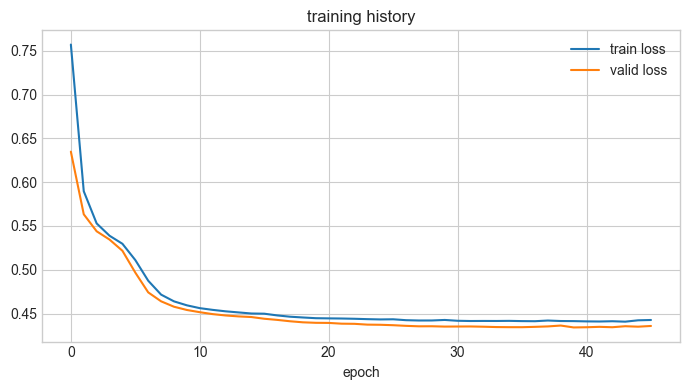

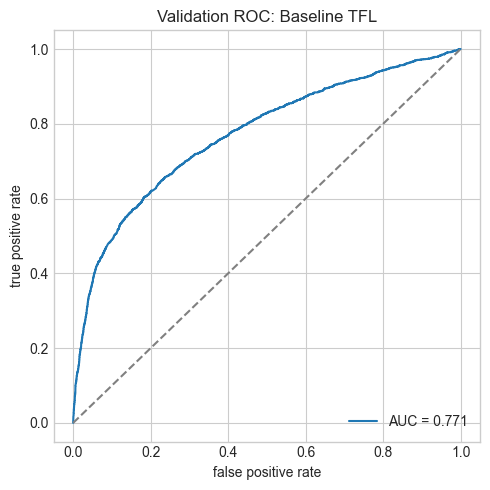

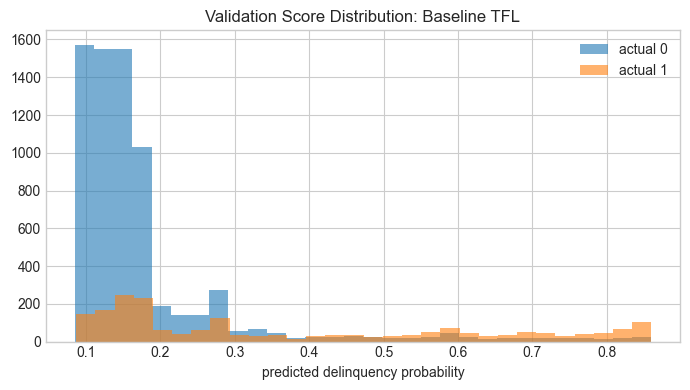

In [6]:
# start with model fit and score separation
plot_history(baseline_model.history)
roc_plot(valid_df[target].to_numpy(), baseline_model.valid_scores, "Validation ROC: Baseline TFL")
score_distribution_plot(baseline_model.valid_scores, valid_df[target].to_numpy(), "Validation Score Distribution: Baseline TFL")
plt.show()

In [7]:
# use the non-negative output weights to pick features to explain
score_weights = baseline_model.model.get_layer("score").get_weights()[0].ravel()
importance_frame = pd.DataFrame({"feature": baseline_model.feature_cols, "weight": score_weights})
importance_frame["abs_weight"] = importance_frame["weight"].abs()
important_features = importance_frame.sort_values("abs_weight", ascending=False)["feature"].head(6).tolist()
importance_frame.sort_values("abs_weight", ascending=False).head(10)

,feature,weight,abs_weight
1,PAY_0,2.021823,2.021823
2,PAY_2,0.612537,0.612537
4,PAY_4,0.415012,0.415012
3,PAY_3,0.350910,0.350910
6,PAY_6,0.300575,0.300575
13,PAY_AMT1,0.295219,0.295219
18,PAY_AMT6,0.246741,0.246741
5,PAY_5,0.198617,0.198617
17,PAY_AMT5,0.167570,0.167570
16,PAY_AMT4,0.152009,0.152009


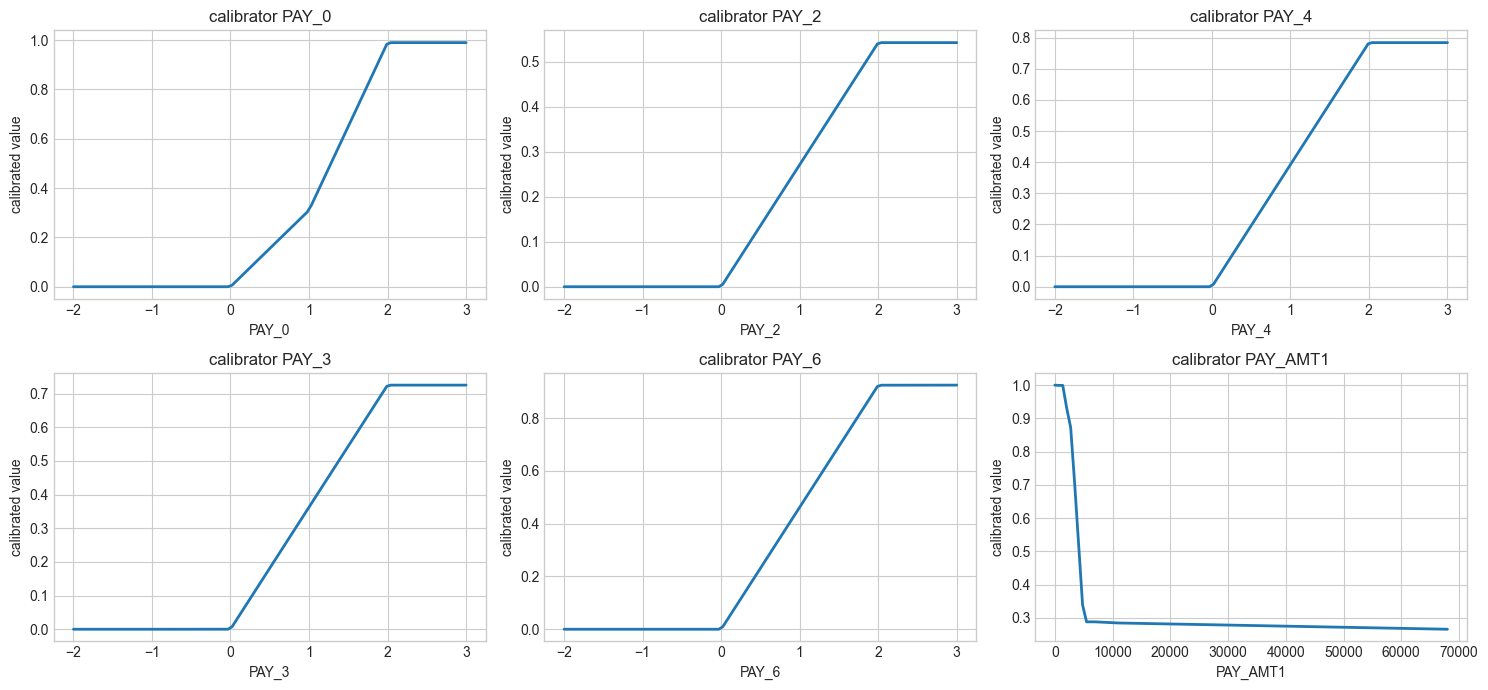

In [8]:
# calibrators show learned feature transforms
plot_calibrators(baseline_model.calibrators, train_df, important_features)
plt.show()

## 6. Baseline Bias Testing

We focus on a compact set of group metrics by race:

- AIR, where favorable means a predicted non-delinquency decision
- FPR
- FNR


In [9]:
baseline_valid_fair.round(3)

,n,favorable_rate,AIR,FPR,FNR
group,,,,,
asian,2769,0.831,0.999,0.124,0.455
black,1762,0.726,0.873,0.123,0.499
hispanic,1758,0.695,0.836,0.129,0.428
white,2711,0.832,1.000,0.125,0.478


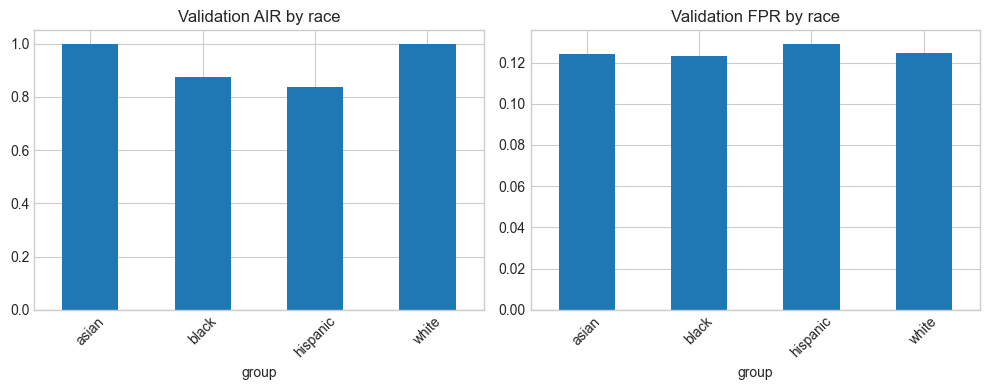

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
baseline_valid_fair["AIR"].plot(kind="bar", ax=axes[0], title="Validation AIR by race")
baseline_valid_fair["FPR"].plot(kind="bar", ax=axes[1], title="Validation FPR by race")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## 7. Remediation 1: Reweighing

We apply simple race-based reweighing on the training data and retrain the same model architecture.

In [11]:
reweighing_weights = compute_reweighing_weights(train_df, group_col="RACE", target_col=target)
reweighing_weights

array([1.2907631 , 1.9949856 , 0.87279433, ..., 1.301209  , 1.2907631 ,
       0.55094814], dtype=float32)

In [12]:
# refit the same architecture with sample weights
reweighed_model = train_variant(
    name="Reweighed TFL",
    train_frame=train_df,
    valid_frame=valid_df,
    columns=feature_cols,
    target_col=target,
    sample_weight=reweighing_weights,
    threshold=0.10,
    num_keypoints=12,
    learning_rate=0.01,
    l1=0.0,
)

reweighed_summary, reweighed_valid_fair = summarize_model(reweighed_model, valid_df, target)
pd.DataFrame([baseline_summary, reweighed_summary]).set_index("model").round(3)

,valid_auc,cutoff,valid_black_AIR,valid_black_FNR,valid_hispanic_AIR,valid_hispanic_FNR
model,,,,,,
Baseline TFL,0.771,0.26,0.873,0.499,0.836,0.428
Reweighed TFL,0.767,0.28,0.875,0.503,0.837,0.422


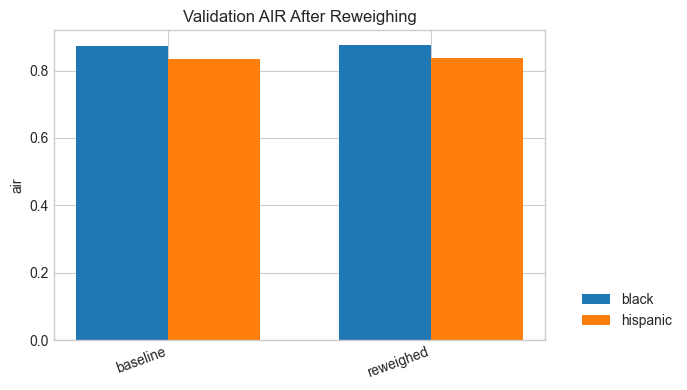

In [13]:
fairness_tables = {
    "baseline": baseline_valid_fair,
    "reweighed": reweighed_valid_fair,
}

_ = plot_group_metric_comparison(fairness_tables, metric="AIR", title="Validation AIR After Reweighing")

## 8. Remediation 2: Small Feature Search

Instead of an exhaustive search, we test a small set of one-feature-drop variants and keep the model with the highest validation hispanic air.

In [14]:
candidate_drops = monotonicity_frame["feature"].head(4).tolist()
feature_candidates = [{"label": "No drop", "drop": None}] + [{"label": f"Drop {col}", "drop": col} for col in candidate_drops]

feature_search_results = []
for candidate in feature_candidates:
    cols = [col for col in feature_cols if col != candidate["drop"]]
    # test one feature drop at a time
    trained_model = train_variant(
        name=candidate["label"],
        train_frame=train_df,
        valid_frame=valid_df,
        columns=cols,
        target_col=target,
        threshold=0.10,
        num_keypoints=12,
        learning_rate=0.01,
        l1=0.0,
    )
    summary, valid_fair = summarize_model(trained_model, valid_df, target)
    feature_search_results.append({"model": trained_model, "summary": summary, "valid_fair": valid_fair})

best_feature_entry = select_highest_hispanic_air(feature_search_results)
best_feature_model = best_feature_entry["model"]
feature_search_table = pd.DataFrame([entry["summary"] for entry in feature_search_results]).set_index("model")
feature_search_table.round(3)

,valid_auc,cutoff,valid_black_AIR,valid_black_FNR,valid_hispanic_AIR,valid_hispanic_FNR
model,,,,,,
No drop,0.767,0.24,0.865,0.481,0.835,0.410
Drop PAY_0,0.735,0.20,0.864,0.536,0.828,0.455
Drop PAY_2,0.766,0.27,0.869,0.489,0.834,0.423
Drop PAY_3,0.768,0.23,0.863,0.461,0.827,0.395
Drop PAY_4,0.767,0.19,0.851,0.434,0.816,0.366


Selected feature-search model: No drop
Active features: 19


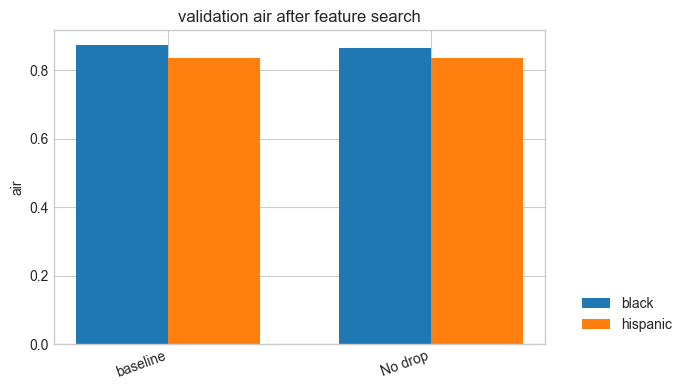

In [15]:
fairness_tables = {
    "baseline": baseline_valid_fair,
    best_feature_model.name: best_feature_entry["valid_fair"],
}

_ = plot_group_metric_comparison(fairness_tables, metric="AIR", title="validation air after feature search")

print(f"Selected feature-search model: {best_feature_model.name}")
print(f"Active features: {len(best_feature_model.feature_cols)}")

## 9. Remediation 3: Small Hyperparameter Search

We keep the selected feature set fixed and search a small grid over calibrator resolution, learning rate, and output sparsity. We keep the model with the highest validation hispanic air.

In [16]:
search_space = [
    {"num_keypoints": 10, "learning_rate": 0.01, "l1": 0.0},
    {"num_keypoints": 12, "learning_rate": 0.01, "l1": 0.0},
    {"num_keypoints": 15, "learning_rate": 0.01, "l1": 1e-4},
    {"num_keypoints": 12, "learning_rate": 0.005, "l1": 1e-4},
    {"num_keypoints": 15, "learning_rate": 0.005, "l1": 5e-4},
]

hyper_search_results = []
for config in search_space:
    label = f"kp={config['num_keypoints']}, lr={config['learning_rate']}, l1={config['l1']}"
    # keep the selected feature set fixed during tuning
    trained_model = train_variant(
        name=label,
        train_frame=train_df,
        valid_frame=valid_df,
        columns=best_feature_model.feature_cols,
        target_col=target,
        threshold=0.10,
        num_keypoints=config["num_keypoints"],
        learning_rate=config["learning_rate"],
        l1=config["l1"],
    )
    summary, valid_fair = summarize_model(trained_model, valid_df, target)
    hyper_search_results.append({"model": trained_model, "summary": summary, "valid_fair": valid_fair})

best_hyper_entry = select_highest_hispanic_air(hyper_search_results)
best_hyper_model = best_hyper_entry["model"]
hyper_search_table = pd.DataFrame([entry["summary"] for entry in hyper_search_results]).set_index("model")
hyper_search_table.round(3)

,valid_auc,cutoff,valid_black_AIR,valid_black_FNR,valid_hispanic_AIR,valid_hispanic_FNR
model,,,,,,
"kp=10, lr=0.01, l1=0.0",0.759,0.19,0.849,0.436,0.813,0.372
"kp=12, lr=0.01, l1=0.0",0.767,0.20,0.846,0.434,0.821,0.374
"kp=15, lr=0.01, l1=0.0001",0.769,0.21,0.836,0.420,0.812,0.360
"kp=12, lr=0.005, l1=0.0001",0.766,0.24,0.869,0.480,0.831,0.405
"kp=15, lr=0.005, l1=0.0005",0.725,0.43,0.892,0.457,0.874,0.439


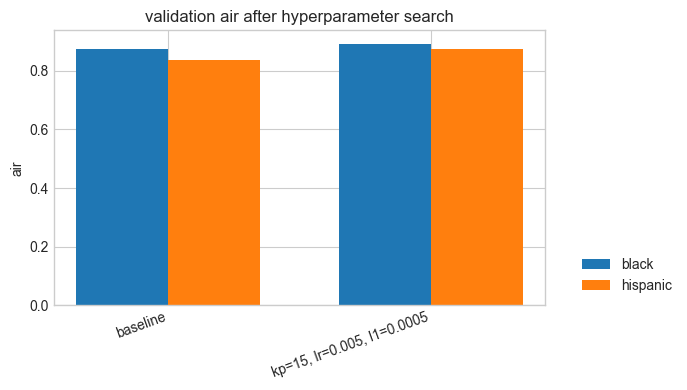

In [17]:
fairness_tables = {
    "baseline": baseline_valid_fair,
    best_hyper_model.name: best_hyper_entry["valid_fair"],
}

_ = plot_group_metric_comparison(fairness_tables, metric="AIR", title="validation air after hyperparameter search")

## 10. Final Comparison

In [18]:
comparison_rows = [
    baseline_summary,
    reweighed_summary,
    best_feature_entry["summary"],
    best_hyper_entry["summary"],
]
comparison = pd.DataFrame(comparison_rows).set_index("model").round(3)
comparison

,valid_auc,cutoff,valid_black_AIR,valid_black_FNR,valid_hispanic_AIR,valid_hispanic_FNR
model,,,,,,
Baseline TFL,0.771,0.26,0.873,0.499,0.836,0.428
Reweighed TFL,0.767,0.28,0.875,0.503,0.837,0.422
No drop,0.767,0.24,0.865,0.481,0.835,0.410
"kp=15, lr=0.005, l1=0.0005",0.725,0.43,0.892,0.457,0.874,0.439
